# Optimisation RB — F(R) avec MILP

## Architecture
1. **Loss binaire** : `loss = 1` si `latence > SLA_max`, sinon `0`
2. **rho estime depuis le debit observe** (robuste en surcharge totale) :
   - `fraction_lost = 0`    → `rho = throughput / cap`
   - `0 < fraction_lost < 0.99` → `rho = throughput / (cap × (1−p))`
   - `fraction_lost >= 0.99` → `rho = 2.0`  (saturation totale, lambda >> cap)
3. **Sigmoid** `p_loss(rho)` calibree par (gNB, slice)
4. **MILP** (scipy) — variables binaires, resolu en millisecondes


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit, milp, LinearConstraint, Bounds
import warnings, os, time
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

CSV_PATH = 'all_simu5g_trans.csv'
OUT_DIR  = 'output_milp/'
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(CSV_PATH)
print(f'Lignes : {len(df):,}  |  Scenarios : {df["Scenario"].nunique()}  |  gNBs : {df["gNB_id"].nunique()}')


Lignes : 255,812  |  Scenarios : 26  |  gNBs : 3


## 1. Parametres reseau

In [2]:
DEFAULT_RBS = {
    'Macro':     {'eMBB': 20, 'URLLC': 17, 'mMTC': 13},
    'Commerce':  {'eMBB': 21, 'URLLC': 11, 'mMTC':  3},
    'Industrie': {'eMBB':  6, 'URLLC': 12, 'mMTC':  7},
}
R_MAX = {'Macro': 50, 'Commerce': 35, 'Industrie': 25}

R_PER_RB = {
    'Macro':     {'eMBB': 0.560, 'URLLC': 0.125, 'mMTC': 0.050},
    'Commerce':  {'eMBB': 0.229, 'URLLC': 0.097, 'mMTC': 0.050},
    'Industrie': {'eMBB': 0.400, 'URLLC': 0.195, 'mMTC': 0.050},
}

SLA = {
    'eMBB':  {'T_min': 10.0,    'L_max_ms':  60.0},   # dataset=50ms, SLA_DETECT=60ms
    'URLLC': {'T_min':  0.5,    'L_max_ms':  25.0},   # dataset=20ms, SLA_DETECT=25ms
    'mMTC':  {'T_min':  0.0003, 'L_max_ms': 300.0},   # correction 3GPP (8.8->300ms)
}

OMEGA_T = 0.6
OMEGA_P = 0.4
SLICES  = ['eMBB', 'URLLC', 'mMTC']
GNBS    = ['Macro', 'Commerce', 'Industrie']

print('Parametres OK.')
print(f'  R_MAX        : {R_MAX}')
print(f'  DEFAULT total: { {g: sum(DEFAULT_RBS[g].values()) for g in GNBS} }')


Parametres OK.
  R_MAX        : {'Macro': 50, 'Commerce': 35, 'Industrie': 25}
  DEFAULT total: {'Macro': 50, 'Commerce': 35, 'Industrie': 25}


## 2. Loss binaire

In [3]:
df['SLA_Latency_Corr'] = df['SLA_Latency_Max_ms'].copy()
df.loc[df['Slice_Type'] == 'mMTC', 'SLA_Latency_Corr'] = 300.0

df['loss_binary'] = (df['Slice_Latency_ms'] > df['SLA_Latency_Corr']).astype(float)
df['is_valid']    = df['loss_binary'] == 0

print('=== Distribution loss binaire ===')
print(df.groupby('Slice_Type')['loss_binary'].agg(['mean','count']).round(3))

print()
print('=== NormalLoad (attendu 0.0) ===')
print(df[df['Scenario'] == 'NormalLoad'].groupby('Slice_Type')['loss_binary'].mean().round(4))

print()
print('=== GlobalSaturation (attendu 1.0 pour eMBB/URLLC) ===')
print(df[df['Scenario'] == 'GlobalSaturation'].groupby('Slice_Type')['loss_binary'].mean().round(4))


=== Distribution loss binaire ===
             mean  count
Slice_Type              
URLLC       0.449  90288
eMBB        0.462  90288
mMTC        0.000  75236

=== NormalLoad (attendu 0.0) ===
Slice_Type
URLLC    0.0
eMBB     0.0
mMTC     0.0
Name: loss_binary, dtype: float64

=== GlobalSaturation (attendu 1.0 pour eMBB/URLLC) ===
Slice_Type
URLLC    1.0
eMBB     1.0
mMTC     0.0
Name: loss_binary, dtype: float64


## 3. Estimation de rho

- `fraction_lost = 0`        → `rho = throughput_mean / cap`
- `0 < fraction_lost < 0.99` → `rho = throughput_mean / (cap × (1 − fraction_lost))`
- `fraction_lost >= 0.99`    → `rho = 2.0`  (saturation totale)

Le debit utilise ici est le **debit total moyen** (pas seulement les paquets valides),
car en saturation Simu5G livre quand meme des paquets depuis le buffer.


In [4]:
# Agregation par (Scenario, gNB, Slice)
agg = df.groupby(['Scenario', 'gNB_id', 'Slice_Type']).agg(
    fraction_lost    = ('loss_binary',           'mean'),
    throughput_mean  = ('Slice_Throughput_Mbps', 'mean'),
).reset_index()

# Capacite par defaut
agg['cap_default'] = agg.apply(
    lambda r: DEFAULT_RBS[r['gNB_id']][r['Slice_Type']] * R_PER_RB[r['gNB_id']][r['Slice_Type']],
    axis=1
)

# Estimation de rho
def estimate_rho(tp, cap, p):
    if p >= 0.99:
        return 2.0                                     # saturation totale
    elif p > 0.01:
        return min(tp / max(cap * (1.0 - p), 1e-6), 3.0)  # surcharge partielle
    else:
        return tp / max(cap, 1e-6)                    # charge normale

agg['rho_base'] = agg.apply(
    lambda r: estimate_rho(r['throughput_mean'], r['cap_default'], r['fraction_lost']),
    axis=1
)

# lambda_base = rho * cap (trafic offert estime)
agg['lambda_base'] = agg['rho_base'] * agg['cap_default']

print('=== Distribution de rho_base par slice ===')
print(agg.groupby('Slice_Type')['rho_base'].describe().round(3))

print()
print('=== rho_base NormalLoad (attendu 0.1 - 0.8) ===')
print(agg[agg['Scenario'] == 'NormalLoad'][
    ['gNB_id','Slice_Type','rho_base','fraction_lost','throughput_mean']].to_string(index=False))

print()
print('=== rho_base GlobalSaturation (attendu >= 1.0 pour eMBB/URLLC) ===')
print(agg[agg['Scenario'] == 'GlobalSaturation'][
    ['gNB_id','Slice_Type','rho_base','fraction_lost']].to_string(index=False))


=== Distribution de rho_base par slice ===
            count   mean    std    min    25%    50%    75%    max
Slice_Type                                                        
URLLC        51.0  1.168  0.934  0.075  0.325  0.714  2.000  3.000
eMBB         51.0  1.418  0.763  0.125  0.699  1.555  2.000  2.861
mMTC         48.0  0.026  0.070  0.001  0.002  0.004  0.027  0.457

=== rho_base NormalLoad (attendu 0.1 - 0.8) ===
   gNB_id Slice_Type  rho_base  fraction_lost  throughput_mean
 Commerce      URLLC  0.299850            0.0         0.319940
 Commerce       eMBB  0.698527            0.0         3.359216
 Commerce       mMTC  0.002507            0.0         0.000376
Industrie      URLLC  0.399299            0.0         0.934360
Industrie       eMBB  0.933121            0.0         2.239490
Industrie       mMTC  0.027420            0.0         0.009597
    Macro      URLLC  0.301148            0.0         0.639939
    Macro       eMBB  0.399934            0.0         4.479260
    Ma

## 4. Calibration sigmoid p_loss(rho)

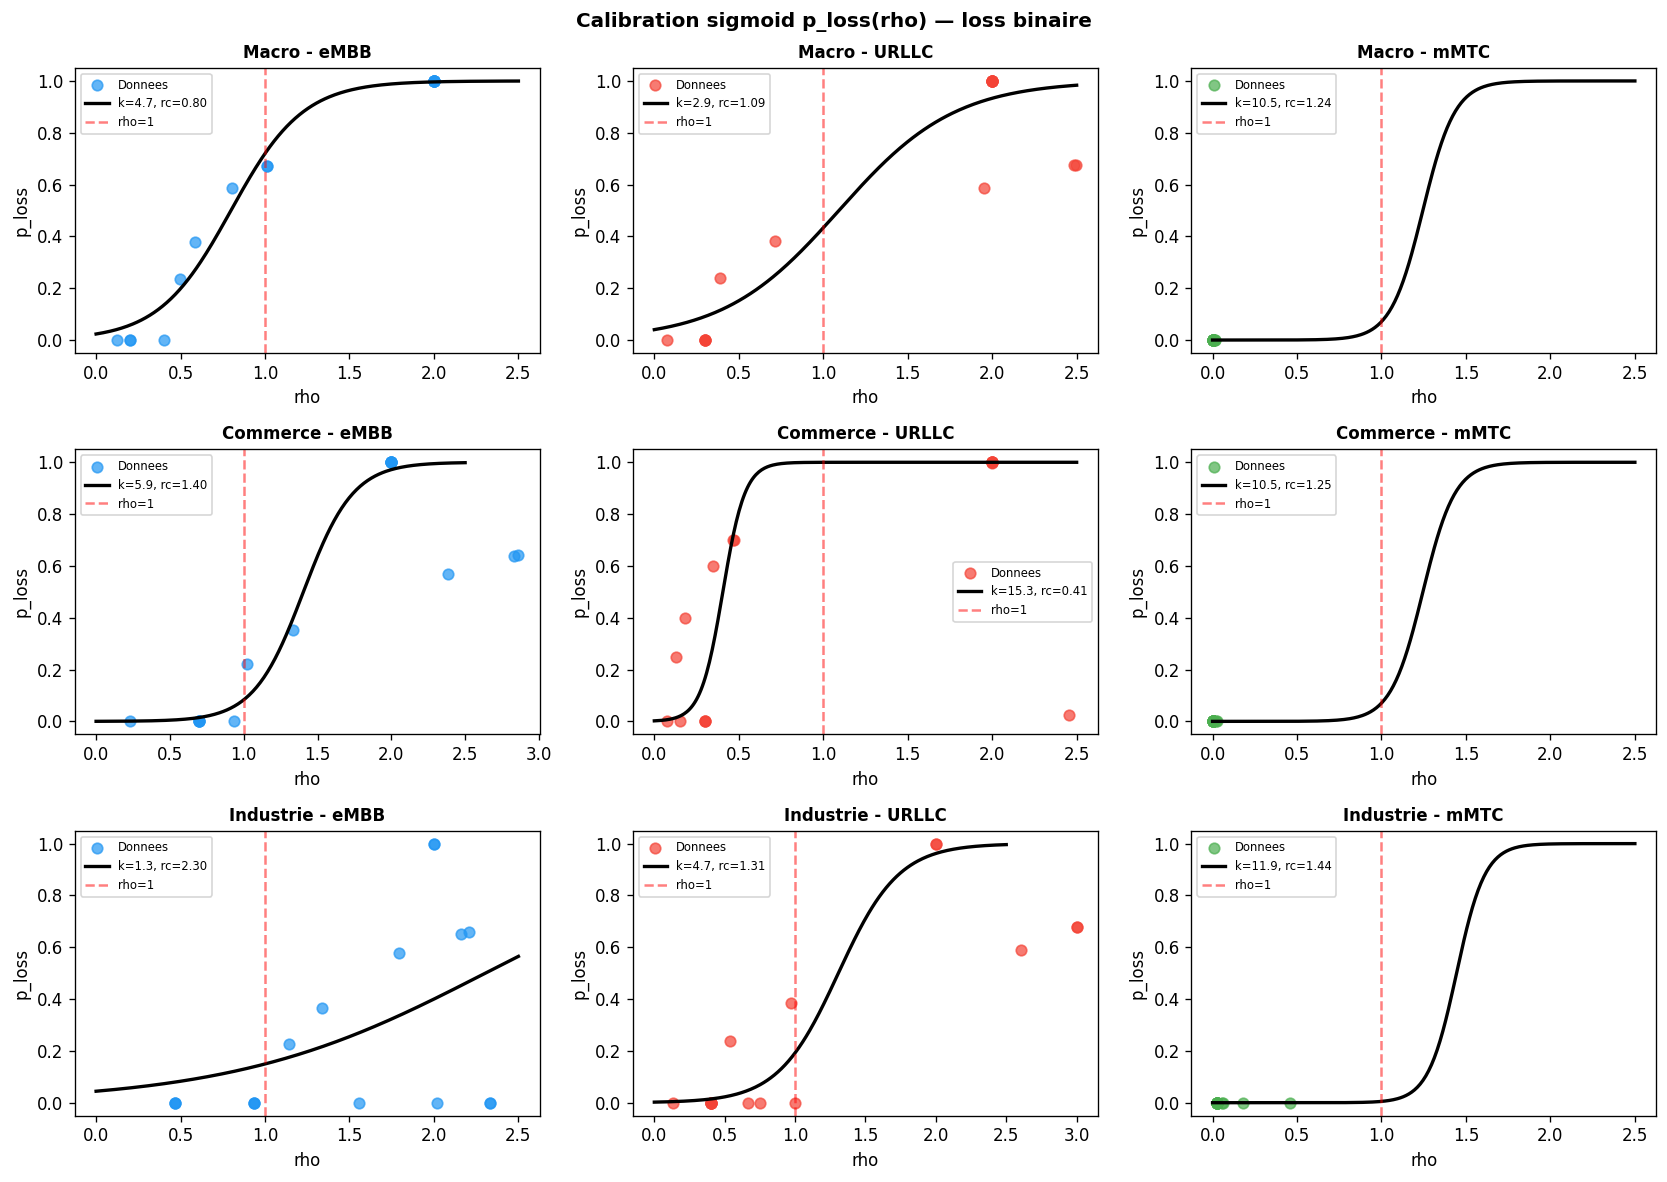

Parametres sigmoid :
  Commerce     URLLC   k=15.27  rho_c=0.406
  Commerce     eMBB    k=5.93  rho_c=1.404
  Commerce     mMTC    k=10.51  rho_c=1.245
  Industrie    URLLC   k=4.67  rho_c=1.307
  Industrie    eMBB    k=1.33  rho_c=2.304
  Industrie    mMTC    k=11.88  rho_c=1.444
  Macro        URLLC   k=2.91  rho_c=1.093
  Macro        eMBB    k=4.68  rho_c=0.798
  Macro        mMTC    k=10.50  rho_c=1.245


In [5]:
def sigmoid(rho, k, rho_c):
    return 1.0 / (1.0 + np.exp(-k * (rho - rho_c)))

sigmoid_params = {}
slice_colors = {'eMBB': '#2196F3', 'URLLC': '#F44336', 'mMTC': '#4CAF50'}

fig, axes = plt.subplots(len(GNBS), len(SLICES), figsize=(14, 10))

for i, gnb in enumerate(GNBS):
    for j, stype in enumerate(SLICES):
        ax = axes[i][j]
        sub = agg[(agg['gNB_id'] == gnb) & (agg['Slice_Type'] == stype)].copy()
        sub = sub.dropna(subset=['rho_base', 'fraction_lost'])

        rho_vals  = sub['rho_base'].values
        loss_vals = sub['fraction_lost'].values

        try:
            popt, _ = curve_fit(
                sigmoid, rho_vals, loss_vals,
                p0=[5.0, 1.0],
                bounds=([0.5, 0.05], [50.0, 3.0]),
                maxfev=10000
            )
            k_fit, rho_c_fit = popt
        except Exception:
            k_fit, rho_c_fit = 5.0, 1.0

        sigmoid_params[(gnb, stype)] = (k_fit, rho_c_fit)

        rho_range = np.linspace(0, 2.5, 300)
        ax.scatter(rho_vals, loss_vals, color=slice_colors[stype], alpha=0.7, s=40, label='Donnees')
        ax.plot(rho_range, sigmoid(rho_range, k_fit, rho_c_fit), 'k-', lw=2,
                label=f'k={k_fit:.1f}, rc={rho_c_fit:.2f}')
        ax.axvline(1.0, color='red', linestyle='--', alpha=0.5, label='rho=1')
        ax.set_title(f'{gnb} - {stype}', fontsize=10, fontweight='bold')
        ax.set_xlabel('rho')
        ax.set_ylabel('p_loss')
        ax.set_ylim(-0.05, 1.05)
        ax.legend(fontsize=7)

plt.suptitle('Calibration sigmoid p_loss(rho) — loss binaire', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + 'sigmoid_calibration_binary.png', bbox_inches='tight')
plt.show()

print('Parametres sigmoid :')
for (gnb, stype), (k, rho_c) in sorted(sigmoid_params.items()):
    print(f'  {gnb:12s} {stype:6s}  k={k:.2f}  rho_c={rho_c:.3f}')


## 5. Tables de cout pre-calculees

Pour chaque (gNB, slice, scenario, k RBs) :
```
rho(k)   = rho_base × R_default / k
cap(k)   = k × R_PER_RB
T_s(k)   = min(lambda_base, cap(k)) × (1 − p(rho(k)))
pen_T(k) = max(0, 1 − T_s / T_min)  si lambda_base >= T_min  sinon 0
cost(k)  = omega_T × pen_T + omega_P × p(rho(k))
```


In [6]:
cost_table = {}
scenario_agg = agg.set_index(['Scenario', 'gNB_id', 'Slice_Type'])

for gnb in GNBS:
    for stype in SLICES:
        k_s, rho_c_s = sigmoid_params[(gnb, stype)]
        R_def = DEFAULT_RBS[gnb][stype]

        for scenario in df['Scenario'].unique():
            key = (gnb, stype, scenario)
            try:
                row      = scenario_agg.loc[(scenario, gnb, stype)]
                rho_base = float(row['rho_base'])
                lam      = float(row['lambda_base'])
            except KeyError:
                cost_table[key] = {k: OMEGA_T * 1.0 + OMEGA_P * 1.0 for k in range(1, R_MAX[gnb]+1)}
                continue

            costs = {}
            for k in range(1, R_MAX[gnb] + 1):
                rho_k = rho_base * R_def / k
                p_s   = float(np.clip(sigmoid(rho_k, k_s, rho_c_s), 0.0, 1.0))
                cap_k = k * R_PER_RB[gnb][stype]
                T_s   = min(lam, cap_k) * (1.0 - p_s)
                T_min = SLA[stype]['T_min']
                pen_T = max(0.0, 1.0 - T_s / T_min) if (lam >= T_min and T_min > 0) else 0.0
                costs[k] = OMEGA_T * pen_T + OMEGA_P * p_s

            cost_table[key] = costs

# Verification : NormalLoad eMBB Macro — le cout doit diminuer avec k
print('=== Cout NormalLoad — Macro eMBB (doit diminuer avec k) ===')
ct = cost_table[('Macro', 'eMBB', 'NormalLoad')]
for k in [1, 5, 10, 20, 30, 50]:
    print(f'  k={k:2d} RBs -> cost = {ct[k]:.4f}')

print()
print('=== Cout GlobalSaturation — Macro URLLC ===')
ct2 = cost_table[('Macro', 'URLLC', 'GlobalSaturation')]
for k in [1, 5, 17, 30, 50]:
    print(f'  k={k:2d} RBs -> cost = {ct2[k]:.4f}')


=== Cout NormalLoad — Macro eMBB (doit diminuer avec k) ===
  k= 1 RBs -> cost = 0.4000
  k= 5 RBs -> cost = 0.3908
  k=10 RBs -> cost = 0.2008
  k=20 RBs -> cost = 0.0537
  k=30 RBs -> cost = 0.0307
  k=50 RBs -> cost = 0.0192

=== Cout GlobalSaturation — Macro URLLC ===
  k= 1 RBs -> cost = 1.0000
  k= 5 RBs -> cost = 1.0000
  k=17 RBs -> cost = 0.8029
  k=30 RBs -> cost = 0.2118
  k=50 RBs -> cost = 0.0927


## 6. MILP — formulation

Variables binaires `x[s][k]` :
- **Objectif** : `min Σ_s Σ_k cost_s(k) · x[s][k]`
- **Selection** : `Σ_k x[s][k] = 1` par slice
- **Budget**    : `Σ_s Σ_k k · x[s][k] = R_MAX[gnb]`


In [7]:
def solve_milp(gnb, scenario):
    R       = R_MAX[gnb]
    n_sl    = len(SLICES)
    n_vars  = n_sl * R

    # Vecteur de cout
    c = np.zeros(n_vars)
    for si, stype in enumerate(SLICES):
        ct = cost_table[(gnb, stype, scenario)]
        for k in range(1, R + 1):
            c[si * R + (k - 1)] = ct[k]

    # Contraintes d'egalite : [selection par slice | budget total]
    n_eq = n_sl + 1
    A_eq = np.zeros((n_eq, n_vars))
    for si in range(n_sl):
        for k in range(1, R + 1):
            A_eq[si,    si * R + (k - 1)] = 1.0
            A_eq[n_sl,  si * R + (k - 1)] = float(k)
    b_eq = np.array([1.0] * n_sl + [float(R)])

    result = milp(
        c,
        constraints=LinearConstraint(A_eq, lb=b_eq, ub=b_eq),
        integrality=np.ones(n_vars),
        bounds=Bounds(lb=0.0, ub=1.0)
    )

    if result.success:
        best_R = {}
        for si, stype in enumerate(SLICES):
            for k in range(1, R + 1):
                if result.x[si * R + (k - 1)] > 0.5:
                    best_R[stype] = k
                    break
        F_opt = result.fun
    else:
        best_R = DEFAULT_RBS[gnb].copy()
        F_opt  = sum(cost_table[(gnb, stype, scenario)][DEFAULT_RBS[gnb][stype]] for stype in SLICES)

    F_def = sum(cost_table[(gnb, stype, scenario)][DEFAULT_RBS[gnb][stype]] for stype in SLICES)
    return best_R, F_opt, F_def

# Test
print('=== NormalLoad — F doit etre bas, allocations equilibrees ===')
for gnb in GNBS:
    best_R, F_opt, F_def = solve_milp(gnb, 'NormalLoad')
    print(f'  {gnb:12s}  F_def={F_def:.3f}  F_opt={F_opt:.3f}  R={best_R}')

print()
print('=== GlobalSaturation — F doit etre eleve ===')
for gnb in GNBS:
    best_R, F_opt, F_def = solve_milp(gnb, 'GlobalSaturation')
    print(f'  {gnb:12s}  F_def={F_def:.3f}  F_opt={F_opt:.3f}  R={best_R}')


=== NormalLoad — F doit etre bas, allocations equilibrees ===
  Macro         F_def=0.090  F_opt=0.064  R={'eMBB': 30, 'URLLC': 19, 'mMTC': 1}
  Commerce      F_def=0.072  F_opt=0.030  R={'eMBB': 18, 'URLLC': 16, 'mMTC': 1}
  Industrie     F_def=0.061  F_opt=0.037  R={'eMBB': 13, 'URLLC': 11, 'mMTC': 1}

=== GlobalSaturation — F doit etre eleve ===
  Macro         F_def=1.799  F_opt=1.099  R={'eMBB': 1, 'URLLC': 48, 'mMTC': 1}
  Commerce      F_def=1.389  F_opt=1.126  R={'eMBB': 33, 'URLLC': 1, 'mMTC': 1}
  Industrie     F_def=1.038  F_opt=0.408  R={'eMBB': 6, 'URLLC': 17, 'mMTC': 2}


## 7. Optimisation sur tous les scenarios

In [8]:
scenarios_list = sorted(df['Scenario'].unique())
results = []

t0 = time.time()
for scenario in scenarios_list:
    for gnb in GNBS:
        best_R, F_opt, F_def = solve_milp(gnb, scenario)
        gain = (F_def - F_opt) / max(F_def, 1e-9) * 100.0
        results.append({
            'Scenario':    scenario, 'gNB': gnb,
            'F_default':   round(F_def, 4),
            'F_optimal':   round(F_opt, 4),
            'gain_pct':    round(gain,  1),
            'R_eMBB_opt':  best_R.get('eMBB',  0),
            'R_URLLC_opt': best_R.get('URLLC', 0),
            'R_mMTC_opt':  best_R.get('mMTC',  0),
            'R_eMBB_def':  DEFAULT_RBS[gnb]['eMBB'],
            'R_URLLC_def': DEFAULT_RBS[gnb]['URLLC'],
            'R_mMTC_def':  DEFAULT_RBS[gnb]['mMTC'],
        })

elapsed = time.time() - t0
df_results = pd.DataFrame(results)
df_results.to_csv(OUT_DIR + 'rb_optimization_results.csv', index=False)

print(f'MILP : {elapsed:.3f}s pour {len(results)} problemes ({elapsed/len(results)*1000:.2f} ms/probleme)')
print()
print(df_results[['Scenario','gNB','F_default','F_optimal','gain_pct']].to_string(index=False))


MILP : 0.380s pour 78 problemes (4.87 ms/probleme)

             Scenario       gNB  F_default  F_optimal  gain_pct
FifaWorldCup_Commerce     Macro     1.7990     1.0987      38.9
FifaWorldCup_Commerce  Commerce     1.3887     1.1256      18.9
FifaWorldCup_Commerce Industrie     0.2095     0.0659      68.5
     GlobalSaturation     Macro     1.7990     1.0987      38.9
     GlobalSaturation  Commerce     1.3887     1.1256      18.9
     GlobalSaturation Industrie     1.0381     0.4078      60.7
 HetLoad_Asymmetric_A     Macro     1.7990     1.0987      38.9
 HetLoad_Asymmetric_A  Commerce     0.0722     0.0298      58.7
 HetLoad_Asymmetric_A Industrie     0.0375     0.0294      21.6
 HetLoad_Asymmetric_B     Macro     0.0594     0.0480      19.2
 HetLoad_Asymmetric_B  Commerce     1.3887     1.1256      18.9
 HetLoad_Asymmetric_B Industrie     0.0375     0.0294      21.6
 HetLoad_Asymmetric_C     Macro     0.0594     0.0480      19.2
 HetLoad_Asymmetric_C  Commerce     0.0723     0.029

## 8. Visualisation

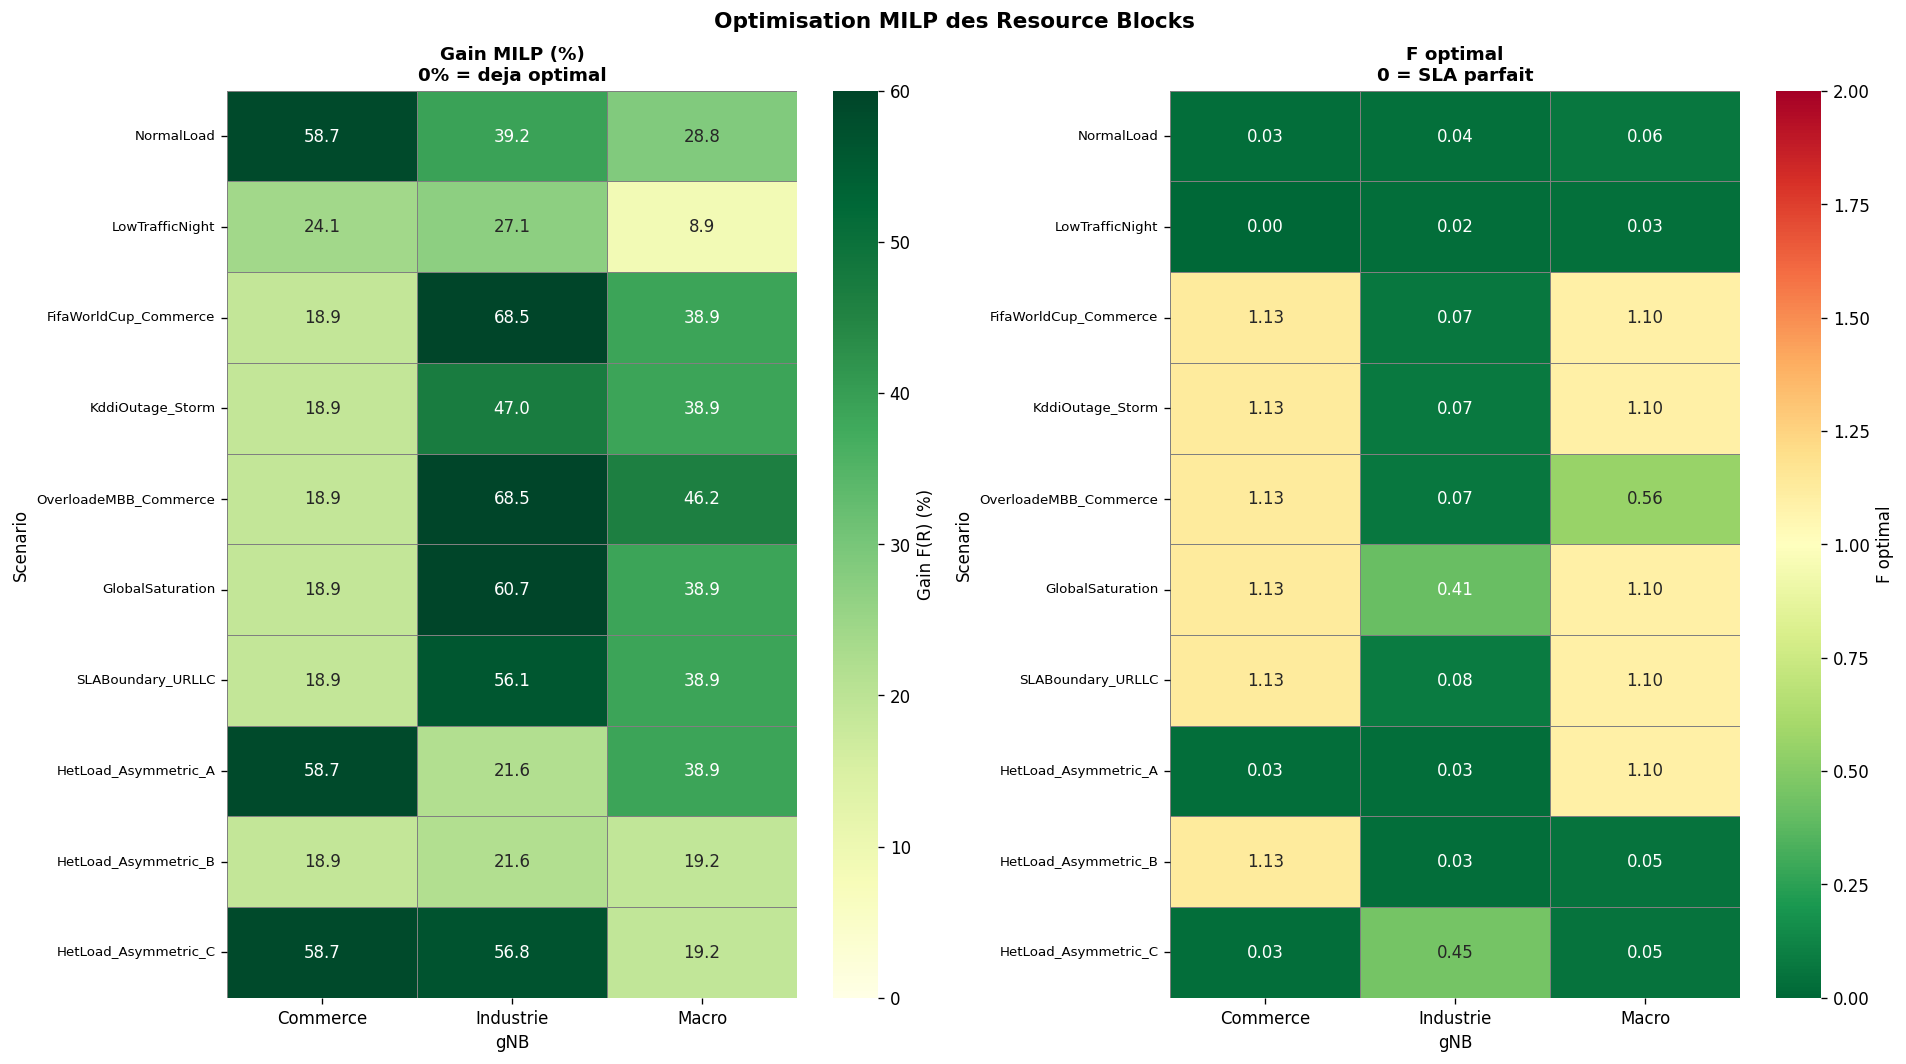

In [9]:
scenario_order = [
    'NormalLoad', 'LowTrafficNight',
    'FifaWorldCup_Commerce', 'KddiOutage_Storm', 'SilverScrapes_Gaming',
    'ClashLaunch_Sync', 'OverloadeMBB_Commerce', 'OverloadURRLC_Industrie',
    'IoTStorm_Industrie', 'GlobalSaturation', 'SLABoundary_URLLC',
    'HetLoad_Asymmetric_A', 'HetLoad_Asymmetric_B', 'HetLoad_Asymmetric_C',
    'HetLoad_FullDiversity', 'RampUp_Commerce', 'FlashCrowd_Macro',
    'PostEvent_Recovery', 'MECShared_Stress', 'EmergencyTraffic_URLLC'
]
scenario_order = [s for s in scenario_order if s in df_results['Scenario'].unique()]

pivot_gain = df_results.pivot_table(index='Scenario', columns='gNB', values='gain_pct')
pivot_gain = pivot_gain.reindex([s for s in scenario_order if s in pivot_gain.index])

pivot_fopt = df_results.pivot_table(index='Scenario', columns='gNB', values='F_optimal')
pivot_fopt = pivot_fopt.reindex([s for s in scenario_order if s in pivot_fopt.index])

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

sns.heatmap(pivot_gain, annot=True, fmt='.1f', cmap='YlGn',
            vmin=0, vmax=60, linewidths=0.5, linecolor='gray',
            ax=axes[0], cbar_kws={'label': 'Gain F(R) (%)'})
axes[0].set_title('Gain MILP (%)\n0% = deja optimal', fontsize=11, fontweight='bold')
plt.setp(axes[0].get_xticklabels(), rotation=0)
plt.setp(axes[0].get_yticklabels(), rotation=0, fontsize=8)

sns.heatmap(pivot_fopt, annot=True, fmt='.2f', cmap='RdYlGn_r',
            vmin=0, vmax=2.0, linewidths=0.5, linecolor='gray',
            ax=axes[1], cbar_kws={'label': 'F optimal'})
axes[1].set_title('F optimal\n0 = SLA parfait', fontsize=11, fontweight='bold')
plt.setp(axes[1].get_xticklabels(), rotation=0)
plt.setp(axes[1].get_yticklabels(), rotation=0, fontsize=8)

plt.suptitle('Optimisation MILP des Resource Blocks', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + 'rb_optimization_milp_heatmap.png', bbox_inches='tight')
plt.show()


## 9. Allocation optimale vs defaut

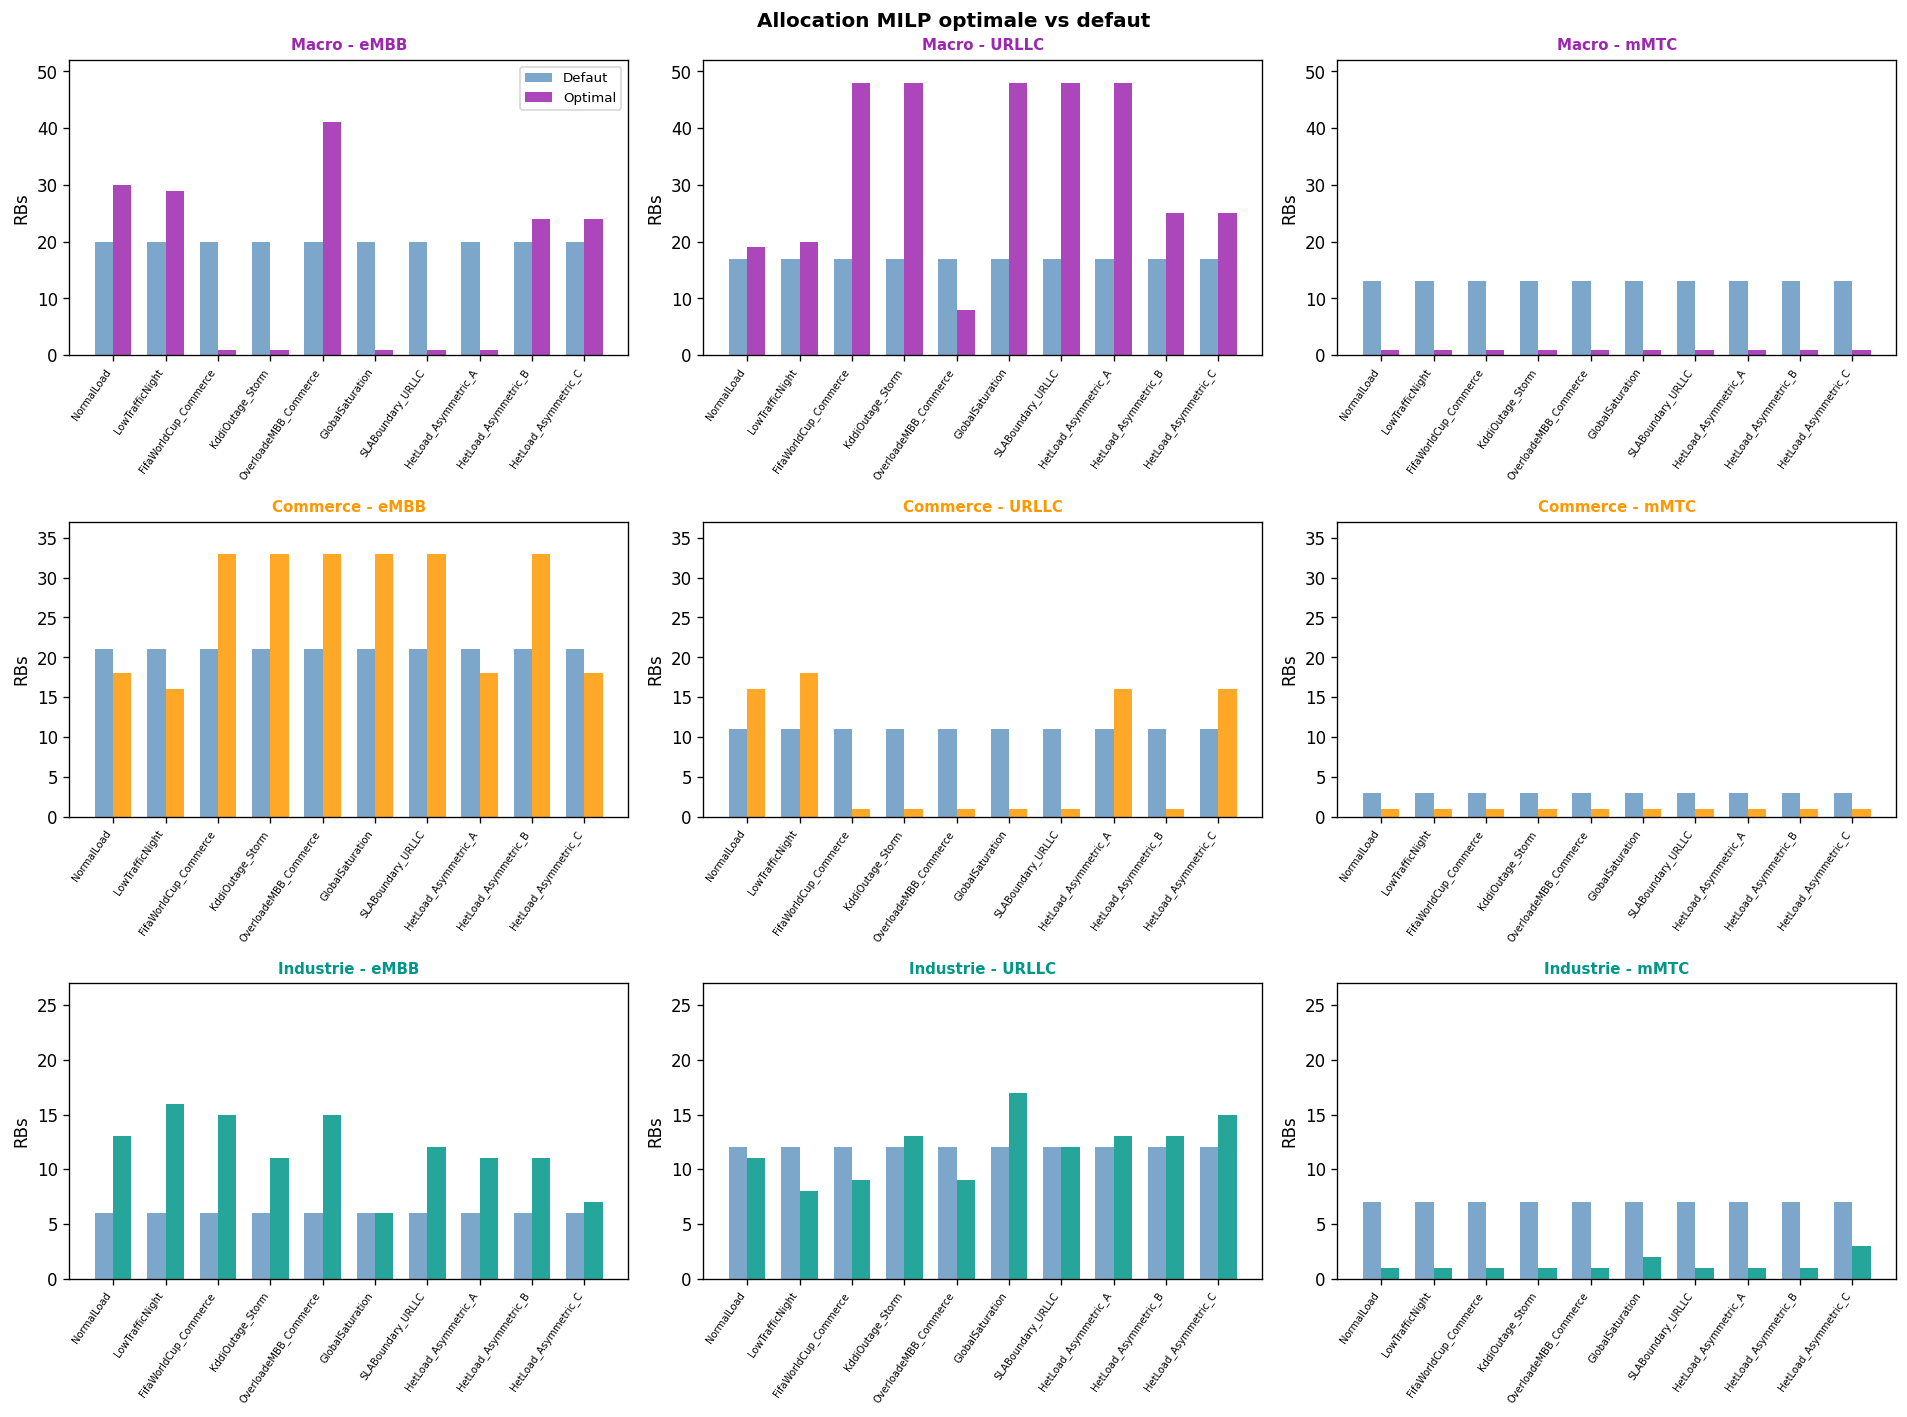

In [10]:
gnb_colors_map = {'Macro': '#9C27B0', 'Commerce': '#FF9800', 'Industrie': '#009688'}
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for row_i, gnb in enumerate(GNBS):
    for col_j, stype in enumerate(SLICES):
        ax = axes[row_i][col_j]
        r_opt_col = f'R_{stype}_opt'
        r_def_col = f'R_{stype}_def'

        sub = df_results[df_results['gNB'] == gnb][['Scenario', r_opt_col, r_def_col]].copy()
        sub = sub.set_index('Scenario')
        sub = sub.reindex([s for s in scenario_order if s in sub.index])

        x = np.arange(len(sub))
        w = 0.35
        ax.bar(x - w/2, sub[r_def_col], w, label='Defaut',  color='steelblue', alpha=0.7)
        ax.bar(x + w/2, sub[r_opt_col], w, label='Optimal', color=gnb_colors_map[gnb], alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(sub.index, rotation=55, ha='right', fontsize=6)
        ax.set_title(f'{gnb} - {stype}', fontsize=9, fontweight='bold', color=gnb_colors_map[gnb])
        ax.set_ylabel('RBs')
        ax.set_ylim(0, R_MAX[gnb] + 2)
        if row_i == 0 and col_j == 0:
            ax.legend(fontsize=8)

plt.suptitle('Allocation MILP optimale vs defaut', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + 'rb_allocation_milp_comparison.png', bbox_inches='tight')
plt.show()


## 10. Resume

In [11]:
print('=== RESUME ===')
print()
print('Gain moyen par gNB :')
print(df_results.groupby('gNB')['gain_pct'].mean().round(2).to_string())
print()
print('Top 10 scenarios (gain moyen sur les 3 gNBs) :')
print(df_results.groupby('Scenario')['gain_pct'].mean().nlargest(10).round(2).to_string())
print()
print('Scenarios avec F_optimal < 0.1 (SLA bien respecte apres optim) :')
ok = df_results[df_results['F_optimal'] < 0.1]
print(ok[['Scenario','gNB','F_optimal']].to_string(index=False))


=== RESUME ===

Gain moyen par gNB :
gNB
Commerce     15.78
Industrie    25.07
Macro        20.72

Top 10 scenarios (gain moyen sur les 3 gNBs) :
Scenario
HetLoad_Asymmetric_C     44.90
OverloadeMBB_Commerce    44.53
NormalLoad               42.23
FifaWorldCup_Commerce    42.10
HetLoad_Asymmetric_A     39.73
GlobalSaturation         39.50
SLABoundary_URLLC        37.97
ModerateLoad_eMBB        35.87
KddiOutage_Storm         34.93
ModerateLoad_URLLC       28.87

Scenarios avec F_optimal < 0.1 (SLA bien respecte apres optim) :
             Scenario       gNB  F_optimal
FifaWorldCup_Commerce Industrie     0.0659
 HetLoad_Asymmetric_A  Commerce     0.0298
 HetLoad_Asymmetric_A Industrie     0.0294
 HetLoad_Asymmetric_B     Macro     0.0480
 HetLoad_Asymmetric_B Industrie     0.0294
 HetLoad_Asymmetric_C     Macro     0.0480
 HetLoad_Asymmetric_C  Commerce     0.0299
     KddiOutage_Storm Industrie     0.0716
      LowTrafficNight     Macro     0.0330
      LowTrafficNight  Commerce     0.0